In [2]:
import pandas as pd
import numpy as np

postings = pd.read_csv("linkedin_job_postings.csv")
skills = pd.read_csv("job_skills.csv")
summary = pd.read_csv("job_summary.csv")

print("Postings:", postings.shape)
print("Skills:", skills.shape)
print("Summary:", summary.shape)

display(postings.head())
display(skills.head())

Postings: (1348454, 14)
Skills: (1296381, 2)
Summary: (1297332, 2)


,job_link,last_processed_time,got_summary,got_ner,is_being_worked,job_title,company,job_location,first_seen,search_city,search_country,search_position,job_level,job_type
0,https://www.linkedin.com/jobs/view/account-exe...,2024-01-21 07:12:29.00256+00,t,t,f,Account Executive - Dispensing (NorCal/Norther...,BD,"San Diego, CA",2024-01-15,Coronado,United States,Color Maker,Mid senior,Onsite
1,https://www.linkedin.com/jobs/view/registered-...,2024-01-21 07:39:58.88137+00,t,t,f,Registered Nurse - RN Care Manager,Trinity Health MI,"Norton Shores, MI",2024-01-14,Grand Haven,United States,Director Nursing Service,Mid senior,Onsite
2,https://www.linkedin.com/jobs/view/restaurant-...,2024-01-21 07:40:00.251126+00,t,t,f,RESTAURANT SUPERVISOR - THE FORKLIFT,Wasatch Adaptive Sports,"Sandy, UT",2024-01-14,Tooele,United States,Stand-In,Mid senior,Onsite
3,https://www.linkedin.com/jobs/view/independent...,2024-01-21 07:40:00.308133+00,t,t,f,Independent Real Estate Agent,Howard Hanna | Rand Realty,"Englewood Cliffs, NJ",2024-01-16,Pinehurst,United States,Real-Estate Clerk,Mid senior,Onsite
4,https://www.linkedin.com/jobs/view/group-unit-...,2024-01-19 09:45:09.215838+00,f,f,f,Group/Unit Supervisor (Systems Support Manager...,"IRS, Office of Chief Counsel","Chamblee, GA",2024-01-17,Gadsden,United States,Supervisor Travel-Information Center,Mid senior,Onsite


,job_link,job_skills
0,https://www.linkedin.com/jobs/view/housekeeper...,"Building Custodial Services, Cleaning, Janitor..."
1,https://www.linkedin.com/jobs/view/assistant-g...,"Customer service, Restaurant management, Food ..."
2,https://www.linkedin.com/jobs/view/school-base...,"Applied Behavior Analysis (ABA), Data analysis..."
3,https://www.linkedin.com/jobs/view/electrical-...,"Electrical Engineering, Project Controls, Sche..."
4,https://www.linkedin.com/jobs/view/electrical-...,"Electrical Assembly, Point to point wiring, St..."


In [3]:
for name, df in {
    "linkedin_job_postings": postings,
    "job_skills": skills,
    "job_summary": summary
}.items():
    print("\n", "=" * 60)
    print(name)
    print("=" * 60)
    print(df.info())


linkedin_job_postings
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1348454 entries, 0 to 1348453
Data columns (total 14 columns):
 #   Column               Non-Null Count    Dtype 
---  ------               --------------    ----- 
 0   job_link             1348454 non-null  object
 1   last_processed_time  1348454 non-null  object
 2   got_summary          1348454 non-null  object
 3   got_ner              1348454 non-null  object
 4   is_being_worked      1348454 non-null  object
 5   job_title            1348454 non-null  object
 6   company              1348443 non-null  object
 7   job_location         1348435 non-null  object
 8   first_seen           1348454 non-null  object
 9   search_city          1348454 non-null  object
 10  search_country       1348454 non-null  object
 11  search_position      1348454 non-null  object
 12  job_level            1348454 non-null  object
 13  job_type             1348454 non-null  object
dtypes: object(14)
memory usage: 144.0+ MB
None


In [4]:
print(postings.columns.tolist())
print(skills.columns.tolist())
print(summary.columns.tolist())

['job_link', 'last_processed_time', 'got_summary', 'got_ner', 'is_being_worked', 'job_title', 'company', 'job_location', 'first_seen', 'search_city', 'search_country', 'search_position', 'job_level', 'job_type']
['job_link', 'job_skills']
['job_link', 'job_summary']


In [5]:
def missing_report(df):
    result = pd.DataFrame({
        "Data Type": df.dtypes.astype(str),
        "Non-Missing Count": df.notna().sum(),
        "Missing Count": df.isna().sum(),
        "Missing %": (df.isna().mean() * 100).round(2),
        "Unique Values": df.nunique(dropna=True)
    })

    return result.sort_values("Missing %", ascending=False)


postings_missing = missing_report(postings)
skills_missing = missing_report(skills)
summary_missing = missing_report(summary)

display(postings_missing)
display(skills_missing)
display(summary_missing)

,Data Type,Non-Missing Count,Missing Count,Missing %,Unique Values
job_link,object,1348454,0,0.0,1348454
last_processed_time,object,1348454,0,0.0,722748
got_summary,object,1348454,0,0.0,2
got_ner,object,1348454,0,0.0,2
is_being_worked,object,1348454,0,0.0,2
job_title,object,1348454,0,0.0,584544
company,object,1348443,11,0.0,90605
job_location,object,1348435,19,0.0,29153
first_seen,object,1348454,0,0.0,6
search_city,object,1348454,0,0.0,1018


,Data Type,Non-Missing Count,Missing Count,Missing %,Unique Values
job_skills,object,1294296,2085,0.16,1287101
job_link,object,1296381,0,0.00,1296381


,Data Type,Non-Missing Count,Missing Count,Missing %,Unique Values
job_link,object,1297332,0,0.0,1297332
job_summary,object,1297332,0,0.0,958192


In [6]:
print("Duplicate rows")

print("Postings:",
      postings.duplicated().sum(),
      f"({postings.duplicated().mean()*100:.2f}%)")

print("Skills:",
      skills.duplicated().sum(),
      f"({skills.duplicated().mean()*100:.2f}%)")

print("Summary:",
      summary.duplicated().sum(),
      f"({summary.duplicated().mean()*100:.2f}%)")

Duplicate rows
Postings: 0 (0.00%)
Skills: 0 (0.00%)
Summary: 0 (0.00%)


In [7]:
print("Unique job links:")
print("Postings:", postings["job_link"].nunique())
print("Skills:", skills["job_link"].nunique())
print("Summary:", summary["job_link"].nunique())

print("\nRows:")
print("Postings:", len(postings))
print("Skills:", len(skills))
print("Summary:", len(summary))

Unique job links:
Postings: 1348454
Skills: 1296381
Summary: 1297332

Rows:
Postings: 1348454
Skills: 1296381
Summary: 1297332


In [8]:
postings_links = set(postings["job_link"].dropna())
skills_links = set(skills["job_link"].dropna())
summary_links = set(summary["job_link"].dropna())

print("Posting records:", len(postings_links))
print("Skill records:", len(skills_links))
print("Summary records:", len(summary_links))

print("\nPostings with skill record:",
      len(postings_links & skills_links))

print("Postings without skill record:",
      len(postings_links - skills_links))

print("Postings with summary:",
      len(postings_links & summary_links))

print("Postings without summary:",
      len(postings_links - summary_links))

Posting records: 1348454
Skill records: 1296381
Summary records: 1297332

Postings with skill record: 1296381
Postings without skill record: 52073
Postings with summary: 1297332
Postings without summary: 51122


In [10]:
skill_join_rate = len(postings_links & skills_links) / len(postings_links) * 100
summary_join_rate = len(postings_links & summary_links) / len(postings_links) * 100

print(f"Skill join coverage: {skill_join_rate:.2f}%")
print(f"Summary join coverage: {summary_join_rate:.2f}%")

Skill join coverage: 96.14%
Summary join coverage: 96.21%


In [11]:
ba_candidates = postings[
    postings["job_title"].fillna("").str.contains(
        r"business.*analyst|analyst.*business",
        case=False,
        regex=True
    )
].copy()

print("Potential Business Analyst postings:", len(ba_candidates))
print("Unique titles:", ba_candidates["job_title"].nunique())

ba_candidates["job_title"].value_counts().head(50)

Potential Business Analyst postings: 6694
Unique titles: 3171


job_title
Business Analyst                                         1011
Senior Business Analyst                                   211
Business Systems Analyst                                  179
JDE Business Analyst (Supply Chain)                       163
JD Edwards Business Analyst                               150
Business Intelligence Analyst                              99
IT Business Analyst                                        64
Business System Analyst                                    62
Technical Business Analyst                                 60
Business Analyst II                                        51
Senior Business Systems Analyst                            41
Business Analyst III                                       36
Business Process Analyst                                   33
Sr. Business Analyst                                       30
Business Data Analyst                                      29
Business Analyst I                                         2

In [12]:
ba = ba_candidates.merge(
    skills,
    on="job_link",
    how="left",
    indicator=True
)

print(ba.shape)

print("\nJoin result:")
print(ba["_merge"].value_counts())

print("\nJoin result (%):")
print((ba["_merge"].value_counts(normalize=True) * 100).round(2))

(6694, 16)

Join result:
_merge
both          6531
left_only      163
right_only       0
Name: count, dtype: int64

Join result (%):
_merge
both          97.56
left_only      2.44
right_only     0.00
Name: proportion, dtype: float64


In [13]:
# Clean title
ba["clean_job_title"] = (
    ba["job_title"]
    .astype("string")
    .str.lower()
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

# Whether usable skill data exist
ba["has_skill_data"] = ba["job_skills"].notna()

# Split skills
ba["skill_list"] = (
    ba["job_skills"]
    .fillna("")
    .str.split(",")
)

# Number of listed skills
ba["skill_count"] = ba["skill_list"].apply(
    lambda x: len([skill for skill in x if skill.strip()])
)

display(
    ba[
        [
            "job_title",
            "clean_job_title",
            "job_skills",
            "has_skill_data",
            "skill_count"
        ]
    ].head()
)

,job_title,clean_job_title,job_skills,has_skill_data,skill_count
0,Secret cleared Business Analyst,secret cleared business analyst,"Microsoft Office 365, Microsoft Teams, SharePo...",True,21
1,Business Analyst (11076-1),business analyst (11076-1),"Technical Writing, Information Security, Micro...",True,28
2,Payment (Swift) (Business Analyst),payment (swift) (business analyst),NaN,False,0
3,Principal Business Analyst,principal business analyst,"NEER, FPL, Reliability reporting, GADS applica...",True,19
4,Business Systems Analyst,business systems analyst,"Customer service skills, General office equipm...",True,21


In [14]:
ba_skills = ba[
    [
        "job_link",
        "job_title",
        "company",
        "job_location",
        "search_country",
        "skill_list"
    ]
].explode("skill_list")

ba_skills["clean_skill"] = (
    ba_skills["skill_list"]
    .astype("string")
    .str.strip()
    .str.lower()
)

# Remove blank skills
ba_skills = ba_skills[
    ba_skills["clean_skill"].notna() &
    (ba_skills["clean_skill"] != "")
]

display(ba_skills.head())

,job_link,job_title,company,job_location,search_country,skill_list,clean_skill
0,https://www.linkedin.com/jobs/view/secret-clea...,Secret cleared Business Analyst,Latitude Inc,"Crystal City, VA",United States,Microsoft Office 365,microsoft office 365
0,https://www.linkedin.com/jobs/view/secret-clea...,Secret cleared Business Analyst,Latitude Inc,"Crystal City, VA",United States,Microsoft Teams,microsoft teams
0,https://www.linkedin.com/jobs/view/secret-clea...,Secret cleared Business Analyst,Latitude Inc,"Crystal City, VA",United States,SharePoint Online,sharepoint online
0,https://www.linkedin.com/jobs/view/secret-clea...,Secret cleared Business Analyst,Latitude Inc,"Crystal City, VA",United States,SharePoint 2016/2019,sharepoint 2016/2019
0,https://www.linkedin.com/jobs/view/secret-clea...,Secret cleared Business Analyst,Latitude Inc,"Crystal City, VA",United States,Microsoft PowerPoint,microsoft powerpoint


In [15]:
skill_frequency = (
    ba_skills.groupby("clean_skill")["job_link"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="job_count")
)

display(skill_frequency.head(30))

,clean_skill,job_count
0,business analysis,2296
1,project management,2237
2,data analysis,2203
3,communication,1953
4,sql,1721
5,analytical skills,1312
6,problem solving,1166
7,communication skills,1156
8,requirements gathering,1005
9,teamwork,954


In [16]:
jobs_with_skills = ba.loc[
    ba["has_skill_data"],
    "job_link"
].nunique()

skill_frequency["percentage_of_jobs_with_skills"] = (
    skill_frequency["job_count"] /
    jobs_with_skills * 100
).round(2)

display(skill_frequency.head(30))

,clean_skill,job_count,percentage_of_jobs_with_skills
0,business analysis,2296,35.16
1,project management,2237,34.26
2,data analysis,2203,33.74
3,communication,1953,29.91
4,sql,1721,26.36
5,analytical skills,1312,20.09
6,problem solving,1166,17.86
7,communication skills,1156,17.70
8,requirements gathering,1005,15.39
9,teamwork,954,14.61


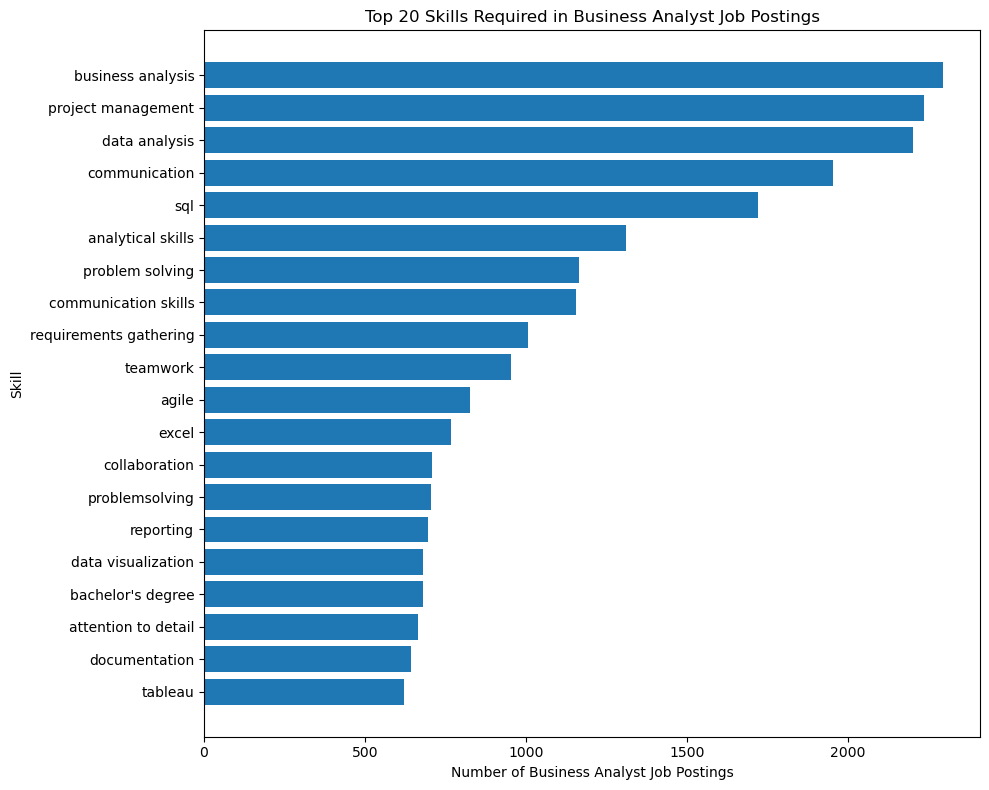

In [18]:
import matplotlib.pyplot as plt

# Count the number of UNIQUE job advertisements containing each skill
skill_frequency = (
    ba_skills.groupby("clean_skill")["job_link"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="job_count")
)

# Select Top 20
top20_frequency = skill_frequency.head(20).sort_values(
    "job_count",
    ascending=True
)

# Plot
plt.figure(figsize=(10, 8))

plt.barh(
    top20_frequency["clean_skill"],
    top20_frequency["job_count"]
)

plt.xlabel("Number of Business Analyst Job Postings")
plt.ylabel("Skill")
plt.title("Top 20 Skills Required in Business Analyst Job Postings")

plt.tight_layout()
plt.show()

Business Analyst jobs with skill data: 6530


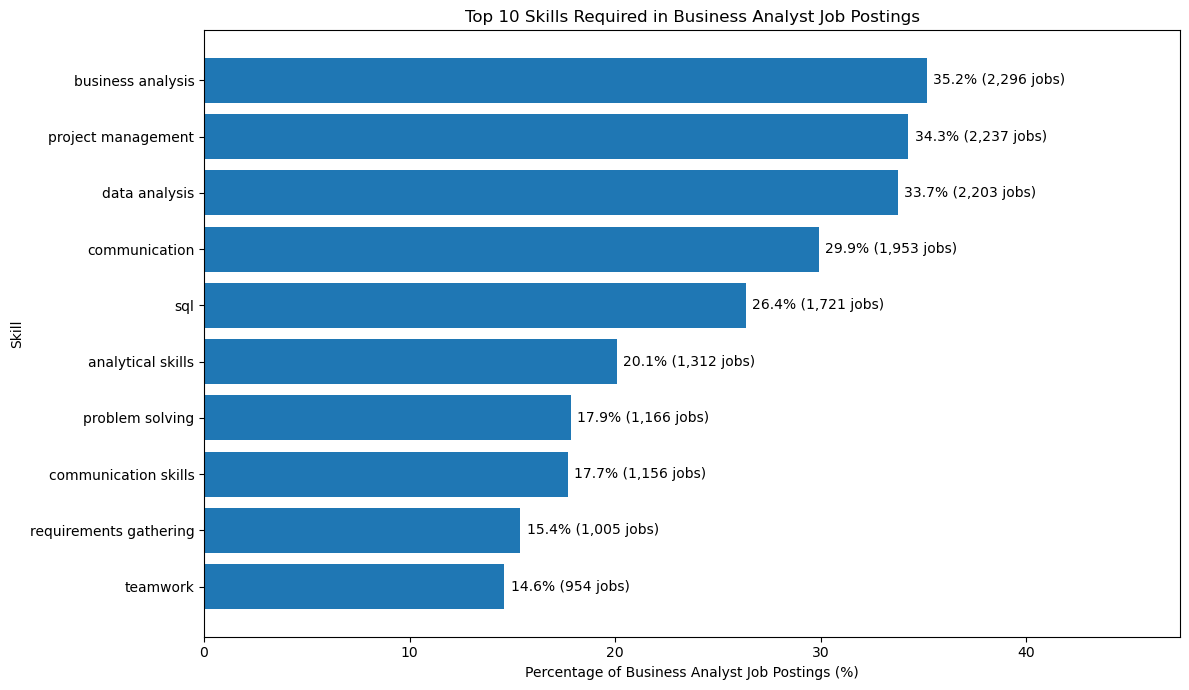

In [19]:
import matplotlib.pyplot as plt

# Number of unique BA job advertisements with usable skill information
jobs_with_skills = ba.loc[
    ba["has_skill_data"],
    "job_link"
].nunique()

print("Business Analyst jobs with skill data:", jobs_with_skills)

# Calculate skill frequency
skill_frequency = (
    ba_skills.groupby("clean_skill")["job_link"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="job_count")
)

# Calculate percentage
skill_frequency["skill_percentage"] = (
    skill_frequency["job_count"]
    / jobs_with_skills
    * 100
).round(2)

# Select Top 10 and sort for horizontal bar chart
top10_percentage = (
    skill_frequency
    .head(10)
    .sort_values("skill_percentage", ascending=True)
)

# Create graph
plt.figure(figsize=(12, 7))

bars = plt.barh(
    top10_percentage["clean_skill"],
    top10_percentage["skill_percentage"]
)

# Axis labels and title
plt.xlabel("Percentage of Business Analyst Job Postings (%)")
plt.ylabel("Skill")
plt.title("Top 10 Skills Required in Business Analyst Job Postings")

# Add BOTH percentage and number of job postings to each bar
for bar, count, percentage in zip(
    bars,
    top10_percentage["job_count"],
    top10_percentage["skill_percentage"]
):
    plt.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{percentage:.1f}% ({count:,} jobs)",
        va="center"
    )

# Add extra space on the right for labels
plt.xlim(
    0,
    top10_percentage["skill_percentage"].max() * 1.35
)

plt.tight_layout()
plt.show()

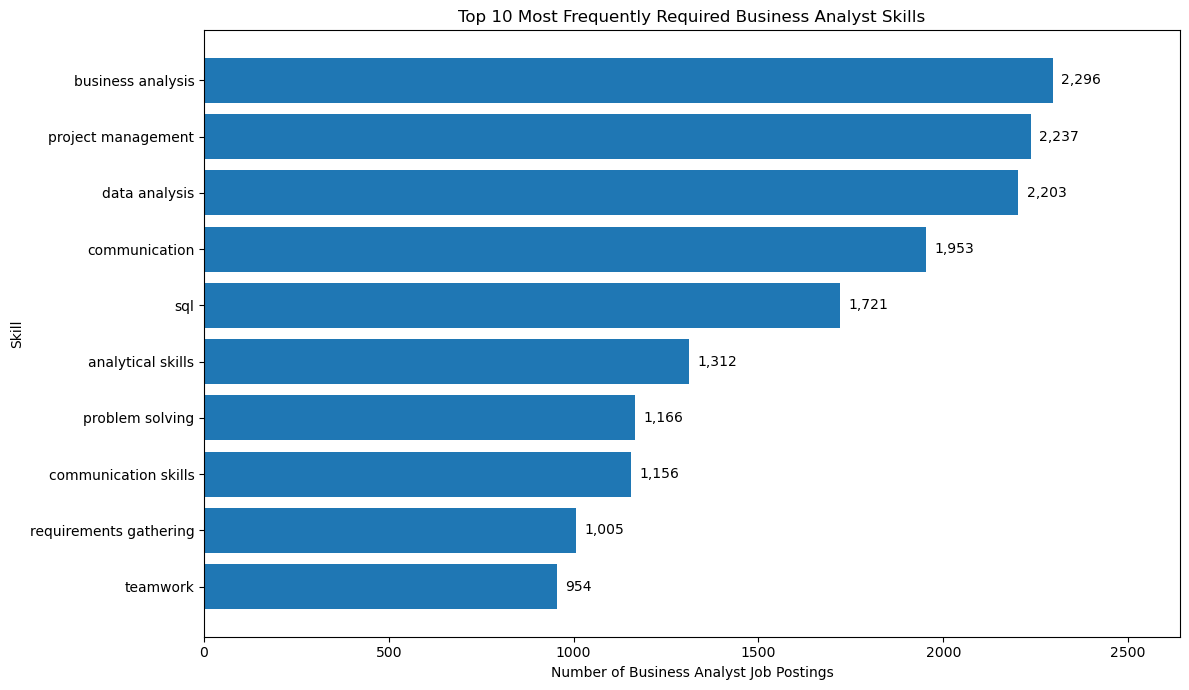

In [20]:
import matplotlib.pyplot as plt

# Count the number of UNIQUE Business Analyst job postings
# containing each skill
skill_frequency = (
    ba_skills.groupby("clean_skill")["job_link"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="job_count")
)

# Select Top 10 skills
top10_frequency = (
    skill_frequency
    .head(10)
    .sort_values("job_count", ascending=True)
)

# Create graph
plt.figure(figsize=(12, 7))

bars = plt.barh(
    top10_frequency["clean_skill"],
    top10_frequency["job_count"]
)

# Add title and axis labels
plt.xlabel("Number of Business Analyst Job Postings")
plt.ylabel("Skill")
plt.title("Top 10 Most Frequently Required Business Analyst Skills")

# Display number of job postings on each bar
for bar, count in zip(
    bars,
    top10_frequency["job_count"]
):
    plt.text(
        bar.get_width() + (top10_frequency["job_count"].max() * 0.01),
        bar.get_y() + bar.get_height() / 2,
        f"{count:,}",
        va="center"
    )

# Add extra space for the labels
plt.xlim(
    0,
    top10_frequency["job_count"].max() * 1.15
)

plt.tight_layout()
plt.show()